# Solving Difference Equations

Some mathematical models use **difference equations** (or linear discrete dynamical systems) to express discrete changes in observed behavior.  

---

## 1. Definition of a First-Order Difference Equation

A first-order linear difference equation models a sequence where each term depends linearly on the previous term. The general form is:

$$x_{n+1} = ax_n + b$$

Where:
* $x_n$ is the state of the system at time step $n$.
* $a$ and $b$ are constants.
* $x_0$ represents the initial condition.

---

## 2. Analytical Solution

To solve the difference equation $x_{n+1} = ax_n + b$ explicitly in terms of $n$ and the initial condition $x_0$, we consider two distinct cases based on the value of $a$.

### Case 1: $a = 1$
When $a = 1$, the equation simplifies to an arithmetic progression:
$$x_{n+1} = x_n + b$$

The general solution is:
$$x_n = x_0 + nb$$

### Case 2: $a \neq 1$
When $a \neq 1$, we can find the solution by unrolling the recurrence relation or finding its equilibrium state. The closed-form solution is:

$$x_n = a^n x_0 + b \left( \frac{1 - a^n}{1 - a} \right)$$

Alternatively, this can be written using the equilibrium value $x^*$ (where $x^* = ax^* + b \Rightarrow x^* = \frac{b}{1-a}$):

$$x_n = a^n(x_0 - x^*) + x^*$$

---

## 3. Long-Term Behavior and Stability

The behavior of the sequence as $n \to \infty$ depends entirely on the value of the multiplier $a$:

| Value of $|a|$ | Stability | Long-Term Behavior ($n \to \infty$) |
| :--- | :--- | :--- |
| $|a| < 1$ | **Stable** | $x_n$ converges to the equilibrium $x^*$ |
| $|a| > 1$ | **Unstable** | $x_n$ diverges toward $\pm \infty$ |
| $a = 1$ | **Neutral** | $x_n$ grows linearly if $b \neq 0$, or stays at $x_0$ if $b = 0$ |
| $a = -1$ | **Neutral** | $x_n$ oscillates indefinitely between two values |

> **Note:** If $a < 0$, the terms of the sequence will alternate signs (oscillate) around the equilibrium point as it either converges or diverges.

---

## 4. Example Problem

**Problem:** Solve the difference equation $x_{n+1} = 0.5x_n + 3$ with an initial condition $x_0 = 10$.

**Step 1: Identify constants**
* $a = 0.5$
* $b = 3$
* $x_0 = 10$

**Step 2: Apply the general solution formula ($a \neq 1$)**
$$x_n = (0.5)^n (10) + 3 \left( \frac{1 - (0.5)^n}{1 - 0.5} \right)$$

**Step 3: Simplify**
$$x_n = 10(0.5)^n + \frac{3}{0.5}(1 - (0.5)^n)$$
$$x_n = 10(0.5)^n + 6(1 - (0.5)^n)$$
$$x_n = 10(0.5)^n + 6 - 6(0.5)^n$$
$$x_n = 4(0.5)^n + 6$$

**Conclusion:** As $n \to \infty$, $(0.5)^n \to 0$, so the system stabilizes at its equilibrium value, $x_n \to 6$.

Let's go ahead and implement a numerical simulation of another example.

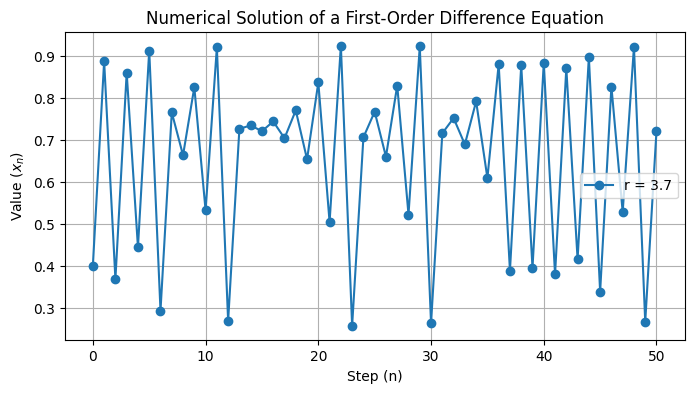

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_difference_equation(x0, r, steps):
    # Allocate array to store values
    x = np.zeros(steps + 1)
    x[0] = x0  # Set initial condition
    
    # Compute subsequent steps sequentially
    for n in range(steps):
        x[n+1] = r * x[n] * (1 - x[n])
        
    return x

# Parameters
initial_value = 0.4
growth_rate = 3.7
total_steps = 50

# Run solver
solution = solve_difference_equation(initial_value, growth_rate, total_steps)

# Plot Results
plt.figure(figsize=(8, 4))
plt.plot(solution, 'o-', label=f'r = {growth_rate}')
plt.xlabel('Step (n)')
plt.ylabel('Value ($x_n$)')
plt.title('Numerical Solution of a First-Order Difference Equation')
plt.grid(True)
plt.legend()
plt.show()


# Solving Higher-Order Difference Equations with the Z-Transform

For higher-order linear discrete dynamical systems (difference equations), the **Z-transform** serves as an advanced operational tool, mapping discrete-time signals from the time domain to the complex Z-domain. It acts as the discrete-time equivalent of the Laplace transform.

---

## 1. Definition of the Z-Transform

The unilateral (one-sided) Z-transform of a discrete sequence $x[n]$ defined for $n \geq 0$ is given by:

$$\mathcal{Z}\{x[n]\} = X(z) = \sum_{n=0}^{\infty} x[n]z^{-n}$$

Where $z$ is a complex variable ($z = r\cdot e^{j\omega}$).

### Key Properties for Solving Difference Equations

To solve difference equations, we rely heavily on the **Time-Shifting Property** (incorporating initial conditions):

* **First Delay:** $\mathcal{Z}\{x[n-1]\} = z^{-1}X(z) + x[-1]$
* **First Advance:** $\mathcal{Z}\{x[n+1]\} = zX(z) - zx[0]$
* **Second Advance:** $\mathcal{Z}\{x[n+2]\} = z^2X(z) - z^2x[0] - zx[1]$

---

## 2. General Solution Methodology

Using the Z-transform to solve a higher-order difference equation follows a structured three-step process:

[ Difference Equation ]
│  (Apply Z-Transform & Initial Conditions)
▼
[ Algebraic Equation in X(z) ]
│  (Isolate X(z) & Use Partial Fractions)
▼
[ Closed-Form Solution x[n] ] (Apply Inverse Z-Transform)

1.  **Transform:** Apply the Z-transform to both sides of the difference equation, substituting the given initial conditions (e.g., $x[0], x[1]$).
2.  **Algebraic Manipulation:** Isolate $X(z)$ algebraically. Typically, you will solve for $\frac{X(z)}{z}$ to simplify the upcoming partial fraction expansion.
3.  **Inverse Transform:** Expand using partial fractions and map the Z-domain terms back to the time domain using standard Z-transform pairs.

---

## 3. Common Z-Transform Pairs


| Sequence $x[n], \quad (n \geq 0)$ | Transform $X(z)$ | Region of Convergence (ROC) |
| :--- | :--- | :--- |
| $\delta[n]$ (Unit Impulse) | $1$ | All $z$ |
| $u[n]$ (Unit Step) | $\frac{z}{z-1}$ | $\lvert z \rvert > 1$ |
| $a^n$ (Exponential) | $\frac{z}{z-a}$ | $\lvert z \rvert > \lvert a \rvert$ |
| $n \cdot a^n$ | $\frac{az}{(z-a)^2}$ | $\lvert z \rvert > \lvert a \rvert$ |


---

## 4. Worked Example: Second-Order System

**Problem:** Solve the second-order difference equation for $n \geq 0$:
$$x[n+2] - 1.5x[n+1] + 0.5x[n] = 0$$
Given initial conditions: $x[0] = 1$ and $x[1] = 2.5$.

### Step 1: Take the Z-Transform
Apply the advance property to each term:
$$\left( z^2X(z) - z^2x[0] - zx[1] \right) - 1.5\left( zX(z) - zx[0] \right) + 0.5X(z) = 0$$

Substitute $x[0] = 1$ and $x[1] = 2.5$:
$$\left( z^2X(z) - z^2 - 2.5z \right) - 1.5\left( zX(z) - z \right) + 0.5X(z) = 0$$

### Step 2: Group Terms and Isolate $X(z)$
$$X(z)\left( z^2 - 1.5z + 0.5 \right) - z^2 - 2.5z + 1.5z = 0$$
$$X(z)\left( z^2 - 1.5z + 0.5 \right) = z^2 + z$$

Divide by $z$ to set up partial fraction expansion:
$$\frac{X(z)}{z} = \frac{z + 1}{z^2 - 1.5z + 0.5}$$

Factor the denominator: $z^2 - 1.5z + 0.5 = (z - 1)(z - 0.5)$
$$\frac{X(z)}{z} = \frac{z + 1}{(z - 1)(z - 0.5)}$$

### Step 3: Partial Fraction Expansion
$$\frac{z + 1}{(z - 1)(z - 0.5)} = \frac{A}{z - 1} + \frac{B}{z - 0.5}$$

* To find $A$, multiply by $(z-1)$ and set $z = 1$: $A = \frac{1 + 1}{1 - 0.5} = \frac{2}{0.5} = 4$
* To find $B$, multiply by $(z-0.5)$ and set $z = 0.5$: $B = \frac{0.5 + 1}{0.5 - 1} = \frac{1.5}{-0.5} = -3$

Substitute $A$ and $B$ back and multiply by $z$:
$$X(z) = 4\left(\frac{z}{z - 1}\right) - 3\left(\frac{z}{z - 0.5}\right)$$

### Step 4: Inverse Z-Transform
Using our standard transform pairs ($1^n = 1$ and $a^n$):
$$x[n] = 4(1)^n - 3(0.5)^n$$

**Final Solution:**
$$x[n] = 4 - 3(0.5)^n \quad \text{for } n \geq 0$$

> **System Stability Note:** Because the roots of the characteristic polynomial (poles of the system) are $z = 1$ and $z = 0.5$, they lie within or on the unit circle ($|z| \leq 1$). As $n \to \infty$, the term $3(0.5)^n \to 0$, causing the system to stably converge to a steady-state value of $4$.

--- Analytical Domain ---
Analytical Solution x[n] = 4.0 - 3.0*0.5**n

--- Numerical Output ---
Step (n)  Numerical x[n]    Analytical x[n]
---------------------------------------------
0         1.0000            1.0000
1         2.5000            2.5000
2         3.2500            3.2500
3         3.6250            3.6250
4         3.8125            3.8125
5         3.9062            3.9062
6         3.9531            3.9531
7         3.9766            3.9766
8         3.9883            3.9883
9         3.9941            3.9941
10        3.9971            3.9971
11        3.9985            3.9985
12        3.9993            3.9993
13        3.9996            3.9996
14        3.9998            3.9998


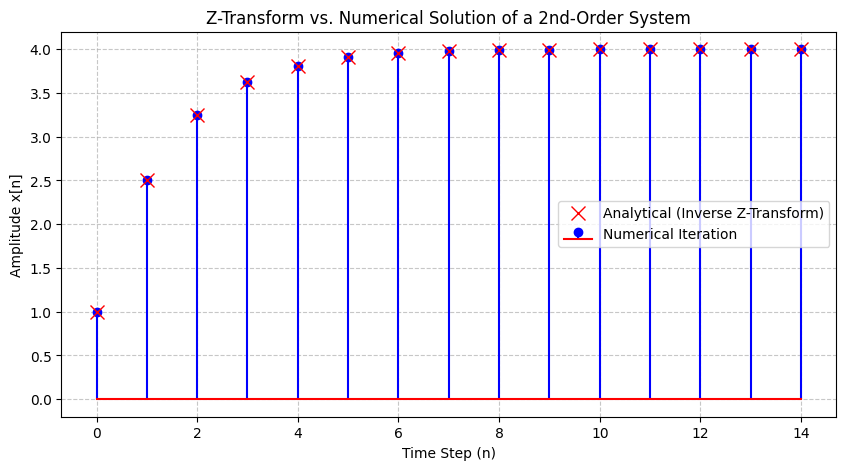

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

def solve_difference_equation_analytically():
    # Define symbols
    n = sp.symbols('n', integer=True, nonnegative=True)
    
    # Define the discrete function x[n]
    x = sp.Function('x')
    
    # Define the difference equation: x[n+2] - 1.5*x[n+1] + 0.5*x[n] = 0
    diff_eq = sp.Eq(x(n+2) - 1.5*x(n+1) + 0.5*x(n), 0)
    
    # Define initial conditions: x[0] = 1.0, x[1] = 2.5
    ics = {x(0): 1.0, x(1): 2.5}
    
    # Solve the recurrence relation analytically
    x_n_expr = sp.rsolve(diff_eq, x(n), ics)
    print("--- Analytical Domain ---")
    print(f"Analytical Solution x[n] = {x_n_expr}\n")
    
    return sp.lambdify(n, x_n_expr, "numpy")

def compute_numerical_solution(steps=15):
    """Computes the numerical solution iteratively directly from the difference equation."""
    # Initialize array for time steps
    x_numerical = np.zeros(steps)

    # Apply initial conditions
    x_numerical[0] = 1.0
    x_numerical[1] = 2.5

    # Iteratively solve: x[n+2] = 1.5*x[n+1] - 0.5*x[n]
    for n in range(0, steps - 2):
        x_numerical[n + 2] = 1.5 * x_numerical[n + 1] - 0.5 * x_numerical[n]

    return x_numerical


# --- Execution and Visualization ---
if __name__ == "__main__":
    num_steps = 15
    time_steps = np.arange(num_steps)

    # 1. Get analytical function
    analytical_func = solve_difference_equation_analytically()
    x_analytical = analytical_func(time_steps)

    # 2. Get numerical iterative sequence
    x_numerical = compute_numerical_solution(steps=num_steps)

    # 3. Output Numerical Solution to Console
    print("--- Numerical Output ---")
    print(f"{'Step (n)':<10}{'Numerical x[n]':<18}{'Analytical x[n]'}")
    print("-" * 45)
    for n in time_steps:
        print(f"{n:<10}{x_numerical[n]:<18.4f}{x_analytical[n]:.4f}")

    # 4. Plot the results to verify they match perfectly
    plt.figure(figsize=(10, 5))
    plt.stem(
        time_steps,
        x_numerical,
        linefmt="b-",
        markerfmt="bo",
        basefmt="r-",
        label="Numerical Iteration",
    )
    plt.plot(
        time_steps,
        x_analytical,
        "rx",
        markersize=10,
        label="Analytical (Inverse Z-Transform)",
    )

    plt.title("Z-Transform vs. Numerical Solution of a 2nd-Order System")
    plt.xlabel("Time Step (n)")
    plt.ylabel("Amplitude x[n]")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()